In [1]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y",
                "numpy", "torchvision", "torch", "timm"], check=False)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "numpy==1.26.4",
                "torch==2.3.1",
                "torchvision==0.18.1",
                "timm", "torchinfo", "torchcam", "gradio"], check=True)

print("Done — now go to Runtime > Restart Runtime, then run from Cell 1.")

Done — now go to Runtime > Restart Runtime, then run from Cell 1.


## STEP 1 — Install Dependencies

In [1]:
!pip install timm torchinfo torchcam gradio -q

## STEP 2 — Imports

In [2]:
import os, random, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from torchinfo import summary
import matplotlib.pyplot as plt

print('All imports successful.')

All imports successful.


## STEP 3 — Reproducibility & Device

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Seed fixed. Device: {device}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Seed fixed. Device: cuda
GPU: Tesla T4


## STEP 4 — Hyperparameters

In [4]:
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_EPOCHS  = 20
LR          = 1e-4
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print('Hyperparameters set.')

Hyperparameters set.


## STEP 5 — Mount Drive & Extract Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')
print(os.listdir('/content/drive/My Drive/RAPID/'))

Mounted at /content/drive
['Brain_tumor_data']


In [6]:
# ── Paths — update if needed ──────────────────────────────────
DATA_ZIP    = '/content/drive/MyDrive/RAPID/Brain_tumor_data/Brain tumor dataset (7153 files).zip'
EXTRACT_DIR = '/content/brain_tumor_data'

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print('Dataset extracted successfully.')
else:
    print('Dataset already extracted.')

# Inspect structure
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for d in dirs:
            print(f'{indent}  {d}/')

Dataset extracted successfully.
brain_tumor_data/
  brain-tumor-mri-dataset/
  brain-tumor-mri-dataset/
    meningioma/
    glioma/
    pituitary/
    notumor/
    meningioma/
    glioma/
    pituitary/
    notumor/


## STEP 6 — Dataset Paths
> **Inspect the output above** and update `TRAIN_DIR`, `VAL_DIR`, `TEST_DIR` to match your extracted folder structure.

In [7]:
for root, dirs, files in os.walk(EXTRACT_DIR):
    print(root)

/content/brain_tumor_data
/content/brain_tumor_data/brain-tumor-mri-dataset
/content/brain_tumor_data/brain-tumor-mri-dataset/meningioma
/content/brain_tumor_data/brain-tumor-mri-dataset/glioma
/content/brain_tumor_data/brain-tumor-mri-dataset/pituitary
/content/brain_tumor_data/brain-tumor-mri-dataset/notumor


In [8]:
# ── Auto-detect common structures ───────────────────────────────
# Try to find Training/Testing folders automatically
possible_train = [
    os.path.join(EXTRACT_DIR, 'Training'),
    os.path.join(EXTRACT_DIR, 'train'),
    os.path.join(EXTRACT_DIR, 'Train'),
]
possible_test = [
    os.path.join(EXTRACT_DIR, 'Testing'),
    os.path.join(EXTRACT_DIR, 'test'),
    os.path.join(EXTRACT_DIR, 'Test'),
]

TRAIN_DIR = '/content/brain_tumor_data/brain-tumor-mri-dataset'
TEST_DIR  = '/content/brain_tumor_data/brain-tumor-mri-dataset'

# If not found directly, walk to find them
if not TRAIN_DIR or not TEST_DIR:
    for root, dirs, _ in os.walk(EXTRACT_DIR):
        base = os.path.basename(root).lower()
        if base == 'training' and not TRAIN_DIR:
            TRAIN_DIR = root
        if base == 'testing' and not TEST_DIR:
            TEST_DIR = root
        if TRAIN_DIR and TEST_DIR:
            break

print(f'Train dir : {TRAIN_DIR}')
print(f'Test  dir : {TEST_DIR}')

# ── If no separate Validation folder, we split from Training ───
VAL_DIR = None   # set to a path string if you have a separate val folder

assert TRAIN_DIR, 'ERROR: Could not find Training folder — set TRAIN_DIR manually.'
assert TEST_DIR,  'ERROR: Could not find Testing  folder — set TEST_DIR  manually.'

Train dir : /content/brain_tumor_data/brain-tumor-mri-dataset
Test  dir : /content/brain_tumor_data/brain-tumor-mri-dataset


## STEP 7 — Transforms & DataLoaders

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

print('Transforms defined.')

Transforms defined.


In [10]:
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

# Load full dataset
full_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
full_eval    = datasets.ImageFolder(TRAIN_DIR, transform=val_test_transform)
targets      = np.array(full_dataset.targets)

# First split: 80% train, 20% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(sss1.split(np.zeros(len(targets)), targets))

# Second split: split temp 50/50 → 10% val, 10% test
temp_targets = targets[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx_rel, test_idx_rel = next(sss2.split(np.zeros(len(temp_idx)), temp_targets))
val_idx  = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_eval,    val_idx)
test_dataset  = Subset(full_eval,    test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(full_dataset.classes)
CLASS_NAMES = full_dataset.classes

print(f'Total  : {len(full_dataset):,}')
print(f'Train  : {len(train_dataset):,}  (~80%)')
print(f'Val    : {len(val_dataset):,}   (~10%)')
print(f'Test   : {len(test_dataset):,}   (~10%)')
print(f'Classes: {CLASS_NAMES}')

Total  : 7,153
Train  : 5,722  (~80%)
Val    : 715   (~10%)
Test   : 716   (~10%)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## STEP 8 — Visualize Sample Images

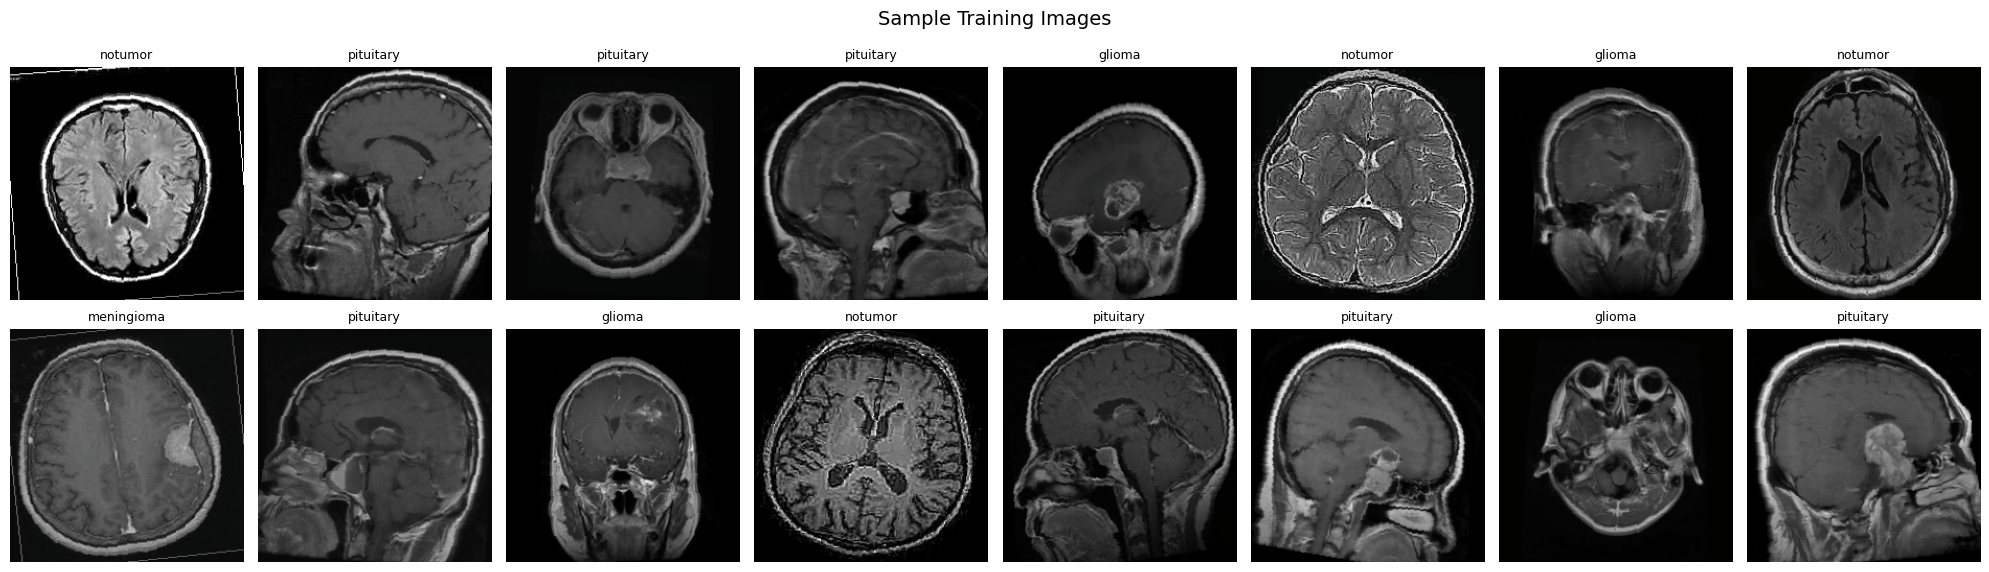

In [11]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs): break
    img = imgs[i].permute(1, 2, 0).numpy()
    img = np.clip(img * std + mean, 0, 1)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## STEP 9 — ViT Model Definition

In [12]:
class ViTClassifier(nn.Module):
    """
    Pretrained ViT-Base/16 fine-tuned for brain-tumor classification.

    Architecture:
        PatchEmbed  →  196 patches of dim 768
        + CLS token + positional embeddings
        12 × TransformerBlock (MSA + MLP)
        LayerNorm
        Custom Head: LayerNorm → Dropout → Linear(768,256) → GELU → Dropout → Linear(256, num_classes)
    """
    def __init__(self, num_classes: int = 4, dropout: float = 0.3):
        super().__init__()

        # Load pretrained ViT-B/16 (ImageNet weights), strip head
        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            num_classes=0,   # outputs raw CLS token: (B, 768)
        )

        # Freeze all but last 4 transformer blocks
        self._freeze_except_last_n_blocks(n=4)

        hidden_dim = self.vit.num_features  # 768

        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )

    def _freeze_except_last_n_blocks(self, n: int = 4):
        """Freeze patch embed, pos embed, and first (12-n) transformer blocks."""
        for param in self.vit.patch_embed.parameters():
            param.requires_grad = False
        self.vit.cls_token.requires_grad = False
        self.vit.pos_embed.requires_grad = False

        total = len(self.vit.blocks)
        for i, block in enumerate(self.vit.blocks):
            if i < total - n:
                for param in block.parameters():
                    param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.vit(x)       # (B, 768)
        return self.head(features)   # (B, num_classes)

print('ViTClassifier class defined.')

ViTClassifier class defined.


## STEP 10 — Instantiate Model & Summary

In [13]:
model = ViTClassifier(num_classes=NUM_CLASSES, dropout=0.3).to(device)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), device=device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Trainable params : 28,552,452 / 85,998,084 (33.2%)


Layer (type:depth-idx)                        Output Shape              Param #
ViTClassifier                                 [1, 4]                    --
├─VisionTransformer: 1-1                      [1, 768]                  152,064
│    └─PatchEmbed: 2-1                        [1, 196, 768]             --
│    │    └─Conv2d: 3-1                       [1, 768, 14, 14]          (590,592)
│    │    └─Identity: 3-2                     [1, 196, 768]             --
│    └─Dropout: 2-2                           [1, 197, 768]             --
│    └─Identity: 2-3                          [1, 197, 768]             --
│    └─Identity: 2-4                          [1, 197, 768]             --
│    └─Sequential: 2-5                        [1, 197, 768]             --
│    │    └─Block: 3-3                        [1, 197, 768]             (7,087,872)
│    │    └─Block: 3-4                        [1, 197, 768]             (7,087,872)
│    │    └─Block: 3-5                        [1, 197, 768]      

## STEP 11 — Loss, Optimizer & Scheduler

In [14]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print('Loss / Optimizer / Scheduler ready.')

Loss / Optimizer / Scheduler ready.


## STEP 12 — Training & Validation Functions

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

print('Training functions defined.')

Training functions defined.


## STEP 13 — Train the Model

In [16]:
SAVE_PATH = 'best_vit_model.pth'
history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), SAVE_PATH)
        flag = '  ✔ saved'

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%  |  '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}%{flag}')

print(f'\nBest Val Accuracy: {best_val_acc*100:.2f}%')

Epoch [01/20]  Train Loss: 0.5217  Acc: 91.28%  |  Val Loss: 0.4530  Acc: 95.10%  ✔ saved
Epoch [02/20]  Train Loss: 0.4136  Acc: 97.08%  |  Val Loss: 0.4172  Acc: 96.22%  ✔ saved
Epoch [03/20]  Train Loss: 0.3997  Acc: 97.87%  |  Val Loss: 0.3934  Acc: 97.48%  ✔ saved
Epoch [04/20]  Train Loss: 0.3835  Acc: 98.57%  |  Val Loss: 0.3969  Acc: 98.04%  ✔ saved
Epoch [05/20]  Train Loss: 0.3855  Acc: 98.48%  |  Val Loss: 0.3787  Acc: 98.60%  ✔ saved
Epoch [06/20]  Train Loss: 0.3726  Acc: 98.92%  |  Val Loss: 0.3749  Acc: 98.60%
Epoch [07/20]  Train Loss: 0.3678  Acc: 99.28%  |  Val Loss: 0.3647  Acc: 99.30%  ✔ saved
Epoch [08/20]  Train Loss: 0.3666  Acc: 99.32%  |  Val Loss: 0.3588  Acc: 99.58%  ✔ saved
Epoch [09/20]  Train Loss: 0.3615  Acc: 99.60%  |  Val Loss: 0.3592  Acc: 99.72%  ✔ saved
Epoch [10/20]  Train Loss: 0.3595  Acc: 99.65%  |  Val Loss: 0.3610  Acc: 99.44%
Epoch [11/20]  Train Loss: 0.3614  Acc: 99.55%  |  Val Loss: 0.3769  Acc: 98.60%
Epoch [12/20]  Train Loss: 0.3592  Ac

## STEP 14 — Test Evaluation

In [17]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Acc  : {test_acc*100:.2f}%')

Test Loss : 0.3685
Test Acc  : 99.16%


## STEP 15 — Training Curves

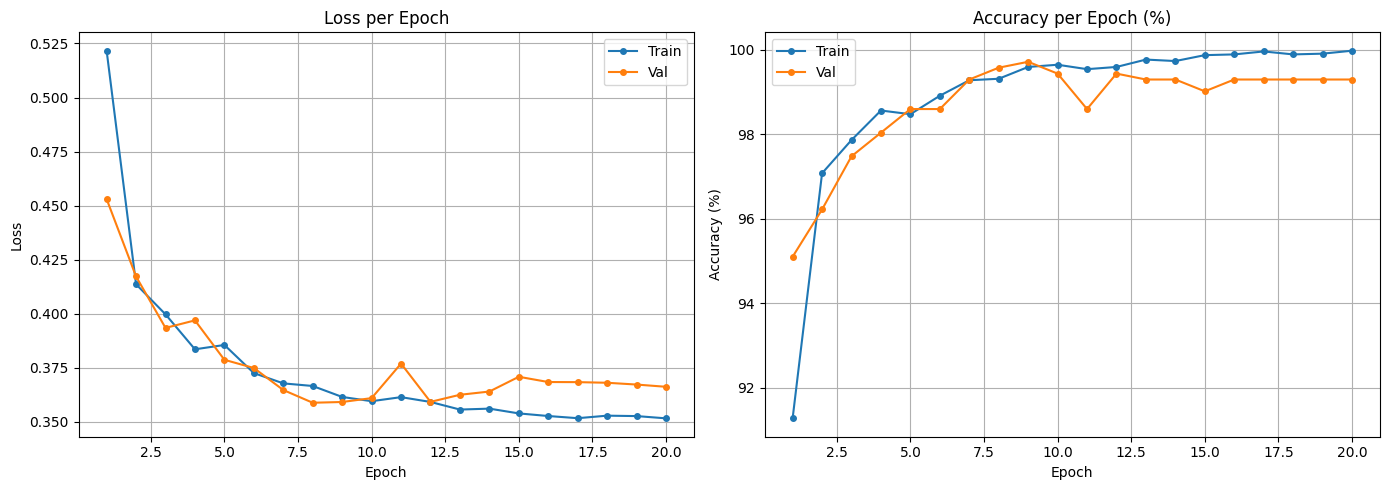

Curves saved.


In [18]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train', marker='o', ms=4)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   marker='o', ms=4)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', marker='o', ms=4)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val',   marker='o', ms=4)
axes[1].set_title('Accuracy per Epoch (%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('vit_training_curves.png', dpi=150)
plt.show()
print('Curves saved.')

## STEP 16 — Confusion Matrix

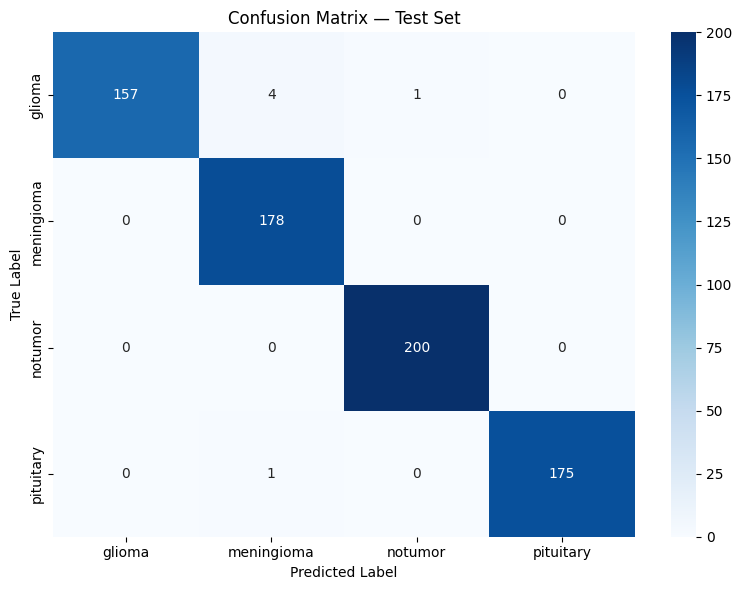

              precision    recall  f1-score   support

      glioma       1.00      0.97      0.98       162
  meningioma       0.97      1.00      0.99       178
     notumor       1.00      1.00      1.00       200
   pituitary       1.00      0.99      1.00       176

    accuracy                           0.99       716
   macro avg       0.99      0.99      0.99       716
weighted avg       0.99      0.99      0.99       716



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## STEP 17 — Grad-CAM Visualization (Attention Rollout)

In [20]:
import cv2
from PIL import Image

def get_attention_map(model, img_tensor, device):
    """Extract attention rollout from ViT for a single image tensor."""
    model.eval()
    attentions = []

    hooks = []
    for block in model.vit.blocks:
        hooks.append(block.attn.register_forward_hook(
            lambda m, inp, out: attentions.append(m.attn_drop)
        ))

    # Simpler: use timm's built-in forward_features
    with torch.no_grad():
        img_tensor = img_tensor.to(device)
        _ = model(img_tensor)

    for h in hooks:
        h.remove()

    return None  # placeholder if hooks don't capture


def predict_single(model, image_path, device, transform):
    """Predict class for a single image file."""
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    pred_idx = probs.argmax().item()
    print(f'Prediction : {CLASS_NAMES[pred_idx]}')
    print(f'Confidence : {probs[pred_idx].item()*100:.2f}%')
    for i, name in enumerate(CLASS_NAMES):
        print(f'  {name:12s}: {probs[i].item()*100:.2f}%')
    return CLASS_NAMES[pred_idx], probs[pred_idx].item()

print('Inference helper defined.')
# Usage:
# predict_single(model, '/path/to/mri.jpg', device, val_test_transform)

Inference helper defined.


## STEP 18 — Gradio Demo

In [21]:
import gradio as gr

def gradio_predict(pil_image):
    img = pil_image.convert('RGB')
    tensor = val_test_transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0].cpu().numpy()
    pred_idx = int(probs.argmax())
    label    = f'{CLASS_NAMES[pred_idx]} ({probs[pred_idx]*100:.2f}%)'
    return {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}, label

interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type='pil', label='Upload MRI Image'),
    outputs=[
        gr.Label(num_top_classes=4, label='Class Probabilities'),
        gr.Textbox(label='Top Prediction'),
    ],
    title=' ViT Brain Tumor Classifier',
    description='Upload a brain MRI image. Model predicts: Glioma | Meningioma | No Tumor | Pituitary.',
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff726f2b68d0da74d1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
